# 01. EDA — 데이터 탐색
INSK corpus 406건 기본 분포 확인
팀원 A 담당

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 데이터 로드
corpus    = pd.read_parquet('../data/insk_corpus.parquet')
analyses  = pd.read_parquet('../data/article_analyses.parquet')
emb_df    = pd.read_parquet('../data/article_embeddings.parquet')
qa_list   = [json.loads(l) for l in open('../data/human_qa_benchmark_v1.jsonl', encoding='utf-8')]

print(f'corpus:    {corpus.shape}')
print(f'analyses:  {analyses.shape}')
print(f'embeddings:{emb_df.shape}')
print(f'QA 개수:   {len(qa_list)}')

corpus:    (406, 8)
analyses:  (406, 8)
embeddings:(406, 3)
QA 개수:   27


## 1. 기본 정보

In [2]:
# 두 테이블 병합 (article_id 기준)
df = corpus.merge(analyses, on='article_id', how='left')
df['published_at'] = pd.to_datetime(df['published_at'])
df['created_at_x'] = pd.to_datetime(df['created_at_x'])

print('컬럼 목록:', df.columns.tolist())
print()
df.head(3)

컬럼 목록: ['article_id', 'title', 'original_url', 'published_at', 'created_at_x', 'source', 'country', 'language', 'analysis_id', 'summary', 'insight', 'category', 'tags', 'user_id', 'created_at_y']



,article_id,title,original_url,published_at,created_at_x,source,country,language,analysis_id,summary,insight,category,tags,user_id,created_at_y
0,151,Overseas AI models outperform Korean rivals in...,https://www.koreatimes.co.kr/path/A20251216144...,2025-12-16 06:28:00,2025-12-23 14:18:17.790104,Naver,KR,ko,85,South Korean AI models were outperformed by ov...,The underperformance of SK Telecom's AI model ...,AI Business,"[""AI"",""CSAT"",""Mathematical Reasoning""]",NaN,2025-12-23 14:18:18.262261
1,152,[RSNA 2025] Lunit takes the front hall as Kore...,https://www.koreabiomed.com/news/articleView.h...,2025-12-15 00:52:00,2025-12-23 14:18:30.252198,Naver,KR,ko,86,Korean AI companies showcased their technologi...,Korean medical-AI firms' experiences at RSNA h...,AI Business,"[""AI"",""Medical Imaging"",""RSNA 2025""]",NaN,2025-12-23 14:18:30.851174
2,153,[Pangyo Interview] Kaier turns internal data i...,https://us.aving.net/news/articleView.html?idx...,2025-12-08 06:26:00,2025-12-23 14:18:36.043587,Naver,KR,ko,87,"Kaier, led by CEO Kyohyuk Lee, has developed a...",Kaier's innovative MLOps solution presents an ...,AI Business,"[""AI automation"",""MLOps"",""industrial AI""]",NaN,2025-12-23 14:18:36.666049


In [3]:
# 결측값 확인
print('=== 결측값 ===')   
print(df[['title','summary','insight','category','tags','source']].isnull().sum())

=== 결측값 ===
title       0
summary     0
insight     0
category    0
tags        0
source      0
dtype: int64


## 2. 카테고리 분포

=== 카테고리 분포 ===
  AI Business    :  226건  (55.7%)
  INFRA          :   64건  (15.8%)
  LLM            :   60건  (14.8%)
  Telco          :   56건  (13.8%)


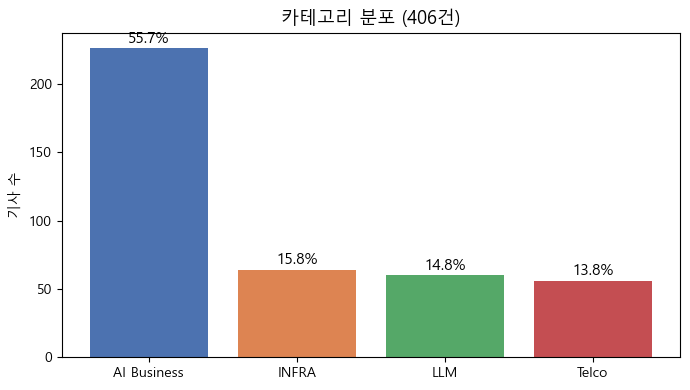


⚠️ AI Business 55.7% 편향 — retrieval 실험 시 카테고리별 분리 평가 권장


In [4]:
cat_counts = df['category'].value_counts()
cat_pct    = df['category'].value_counts(normalize=True) * 100

print('=== 카테고리 분포 ===')
for cat in cat_counts.index:
    print(f'  {cat:15s}: {cat_counts[cat]:4d}건  ({cat_pct[cat]:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cat_counts.index, cat_counts.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
for bar, pct in zip(bars, cat_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_title('카테고리 분포 (406건)', fontsize=13)
ax.set_ylabel('기사 수')
plt.tight_layout()
plt.show()

print('\n⚠️ AI Business 55.7% 편향 — retrieval 실험 시 카테고리별 분리 평가 권장')
print()
print("="*55)
print("⚠️  category 컬럼 사용 주의")
print("="*55)
print("분류기 편향: AI 회사·정책 기사가 AI Business로 과도하게 묶임")
print("→ corpus를 category로 직접 필터링하면 LLM·INFRA 기사 누락 위험")
print("→ 대신 summary·tags 키워드 매칭으로 관련 기사 직접 찾기")
print()
print("올바른 사용 예시:")
print("  ❌ df[df[category]==LLM]  # 4%밖에 안 잡힘")
print("  ✅ df[df[tags].str.contains(LLM|GPT|Gemini)]")


## 3. 매체(source) 분포

=== 매체 분포 ===
  Naver     :  286건  (70.4%)
  AITimes   :   60건  (14.8%)
  TheGuru   :   60건  (14.8%)


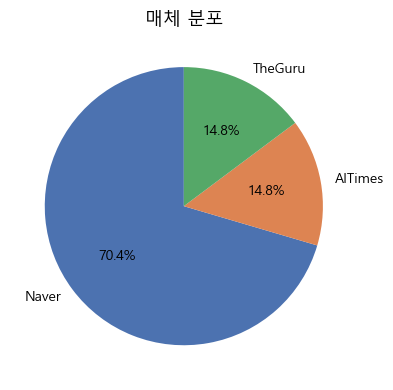


⚠️ Naver 70.4% 편향 — 매체별 균형 평가 권장


In [5]:
src_counts = df['source'].value_counts()
src_pct    = df['source'].value_counts(normalize=True) * 100

print('=== 매체 분포 ===')
for src in src_counts.index:
    print(f'  {src:10s}: {src_counts[src]:4d}건  ({src_pct[src]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(src_counts.values, labels=src_counts.index,
       autopct='%1.1f%%', startangle=90,
       colors=['#4C72B0','#DD8452','#55A868'])
ax.set_title('매체 분포', fontsize=13)
plt.tight_layout()
plt.show()

print('\n⚠️ Naver 70.4% 편향 — 매체별 균형 평가 권장')

## 4. 날짜 분포

2026-05-19 이후: 252건 (Temporal weighting 사용 가능)
2026-05-19 이전: 154건 (published_at 일부 부정확, 주의)


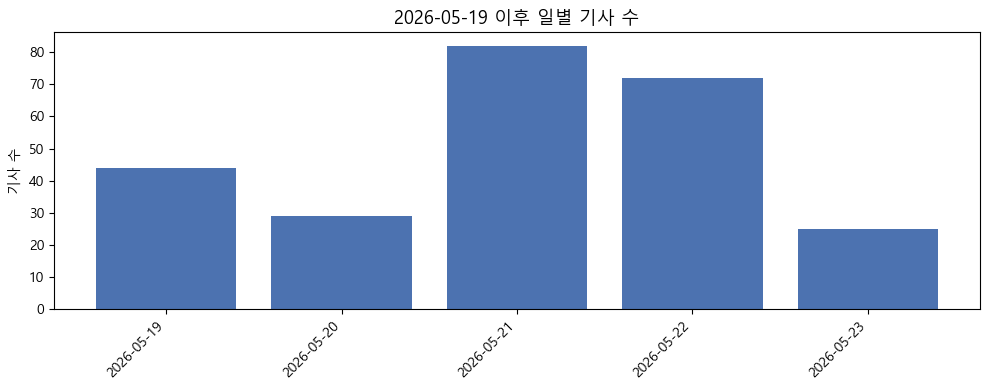

In [6]:
df_recent = df[df['published_at'] >= '2026-05-19'].copy()
df_old    = df[df['published_at'] <  '2026-05-19'].copy()

print(f'2026-05-19 이후: {len(df_recent)}건 (Temporal weighting 사용 가능)')
print(f'2026-05-19 이전: {len(df_old)}건 (published_at 일부 부정확, 주의)')

# 최근 데이터 날짜별 분포
daily = df_recent.groupby(df_recent['published_at'].dt.date).size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(daily.index.astype(str), daily.values, color='#4C72B0')
ax.set_title('2026-05-19 이후 일별 기사 수', fontsize=13)
ax.set_ylabel('기사 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. 텍스트 길이 분포

In [7]:
df['title_len']   = df['title'].str.len()
df['summary_len'] = df['summary'].fillna('').str.len()
df['insight_len'] = df['insight'].fillna('').str.len()

print('=== 텍스트 길이 통계 (문자 수) ===')
for col in ['title_len', 'summary_len', 'insight_len']:
    print(f'  {col:15s}: 평균 {df[col].mean():.0f}자  최대 {df[col].max()}자  최소 {df[col].min()}자')

print('\n→ BM25 인덱스 텍스트 = title + summary + insight + tags 조합 예정')
print('  평균 검색 가능 텍스트: 약', int(df['title_len'].mean() + df['summary_len'].mean() + df['insight_len'].mean()), '자/기사')

=== 텍스트 길이 통계 (문자 수) ===
  title_len      : 평균 40자  최대 76자  최소 9자
  summary_len    : 평균 214자  최대 738자  최소 31자
  insight_len    : 평균 80자  최대 323자  최소 20자

→ BM25 인덱스 텍스트 = title + summary + insight + tags 조합 예정
  평균 검색 가능 텍스트: 약 334 자/기사


## 6. QA Benchmark 분석

In [8]:
strict   = [q for q in qa_list if q['type'] == 'Strict']
trend    = [q for q in qa_list if q['type'] == 'Trend']
negative = [q for q in qa_list if q['type'] == 'Negative']

print(f'전체 QA: {len(qa_list)}개')
print(f'  Strict:   {len(strict)}개  — 정답 1-2개 명확 (BM25 강점 예상)')
print(f'  Trend:    {len(trend)}개  — 정답 다수 (Embedding 강점 예상)')
print(f'  Negative: {len(negative)}개  — corpus에 정답 없음 (hallucination 평가용)')

print('\n=== Strict 질문 목록 ===')
for q in strict:
    print(f'  [{q["id"]}] {q["question"]}')
    print(f'       gold_articles: {q["gold_articles"]}')

print('\n=== Trend 질문 목록 ===')
for q in trend:
    print(f'  [{q["id"]}] {q["question"]}')

print('\n=== Negative 질문 목록 ===')
for q in negative:
    print(f'  [{q["id"]}] {q["question"]}')

전체 QA: 27개
  Strict:   7개  — 정답 1-2개 명확 (BM25 강점 예상)
  Trend:    14개  — 정답 다수 (Embedding 강점 예상)
  Negative: 6개  — corpus에 정답 없음 (hallucination 평가용)

=== Strict 질문 목록 ===
  [L1] OpenAI가 최근 발표한 신모델·기능은?
       gold_articles: [519, 317]
  [L3] Anthropic 매출·사업 동향은?
       gold_articles: [427, 345]
  [I1] 삼성전자 AI 반도체 전략은?
       gold_articles: [491, 288]
  [B1] OpenAI IPO·매출 동향은?
       gold_articles: [315, 319]
  [B2] 최근 AI M&A 사례는?
       gold_articles: [405, 407, 408]
  [B5] 한국 정부 AI 정책·투자는?
       gold_articles: [431]
  [T1] SKT AI 서비스·전략은?
       gold_articles: [281, 482, 487]

=== Trend 질문 목록 ===
  [L2] AI 에이전트 시장 최근 동향은?
  [L4] Gemini·구글의 AI 전략은?
  [L5] 멀티모달 AI 주요 사례는?
  [L6] 오픈소스 LLM 동향은?
  [I3] NVIDIA AI 칩 동향은?
  [I6] on-device·Edge AI 칩 동향은?
  [B3] AI 스타트업 투자 동향은?
  [B4] 글로벌 AI 정책·규제 동향은?
  [B6] 생성형 AI 시장 동향은?
  [B7] 글로벌 AI 허브 경쟁은?
  [B8] 빅테크 AI 투자 규모는?
  [B9] AI 일자리·고용 영향은?
  [T5] 통신사 데이터센터 사업은?
  [T6] 통신사 AI 에이전트 서비스는?

=== Negative 질문 목록 ===
  [I2] SK하이닉스·HBM 시장 동향은?
  [I4] 국내 

## 7. Gold article이 corpus에 있는지 확인

In [9]:
corpus_ids = set(corpus['article_id'].tolist())

print('=== Gold article corpus 존재 여부 ===')
missing = []
for q in qa_list:
    if q['type'] == 'Negative':
        continue
    for gid in q['gold_articles']:
        if gid not in corpus_ids:
            missing.append((q['id'], gid))
            print(f'  ⚠️ QA [{q["id"]}] gold_article {gid} — corpus에 없음')

if not missing:
    print('  ✅ 모든 gold_article이 corpus에 존재')
else:
    print(f'\n  → {len(missing)}개 누락. 해당 QA는 평가에서 제외하거나 partial로 처리')

=== Gold article corpus 존재 여부 ===
  ✅ 모든 gold_article이 corpus에 존재


## 8. EDA 요약

In [10]:
print('='*50)
print('EDA 요약')
print('='*50)
print(f'총 기사: {len(df)}건')
print(f'카테고리 편향: AI Business {cat_pct.get("AI Business",0):.1f}%')
print(f'매체 편향:     Naver {src_pct.get("Naver",0):.1f}%')
print(f'Temporal 사용 가능: {len(df_recent)}건 (2026-05-19 이후)')
print(f'QA 평가셋: {len(qa_list)}개 (Strict {len(strict)} / Trend {len(trend)} / Negative {len(negative)})')
print()
print('02_retrieval_baseline 시작 가능')

EDA 요약
총 기사: 406건
카테고리 편향: AI Business 55.7%
매체 편향:     Naver 70.4%
Temporal 사용 가능: 252건 (2026-05-19 이후)
QA 평가셋: 27개 (Strict 7 / Trend 14 / Negative 6)

02_retrieval_baseline 시작 가능
